# Desafio: Classificação de Reclamações Financeiras e Análise das Dores dos Clientes

Olá! Este notebook foi criado para resolver o desafio da Fase 5 do Datathon. O objetivo principal é analisar reclamações de consumidores sobre produtos financeiros, classificar o sentimento dessas mensagens e identificar os principais problemas enfrentados pelos clientes.

Nesta análise, vamos passar pelas seguintes etapas:
1. **Carregamento e Exploração dos Dados**: Entender o que temos em mãos.
2. **Pré-processamento de Texto**: Limpar os dados para que o computador entenda melhor (incluindo a remoção de dados anonimizados).
3. **Criação da Variável Alvo**: Definir o que é um sentimento 'Positivo' ou 'Negativo'.
4. **Modelagem com Deep Learning**: Treinar um modelo para classificar novas reclamações.
5. **Análise das Dores dos Clientes**: Visualizar os termos mais comuns e entender as insatisfações.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from sklearn.metrics import classification_report, confusion_matrix

# Downloads necessários do NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1. Carregamento dos Dados

Vamos carregar a amostra de mais de 143.000 reclamações que baixamos diretamente da base do CFPB.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/complaints_143k.csv', engine='python', quotechar='"', escapechar='\\', on_bad_lines='skip')
print(f"Total de registros: {len(df)}")
df.head()

Total de registros: 143563


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,01/05/24,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report....,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,01/05/24,Closed with non-monetary relief,Yes,NaN,8113747
1,10/22/19,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,XXXX XXXX has a old account settled in XXXX th...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,HI,967XX,Servicemember,Consent provided,Web,10/22/19,Closed with non-monetary relief,Yes,NaN,3414709
2,05/08/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,05/08/20,Closed with explanation,Yes,NaN,3642453
3,03/19/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,"I wrote three requests, the unverified account...",NaN,"EQUIFAX, INC.",NC,28562,NaN,Consent provided,Web,03/19/20,Closed with explanation,Yes,NaN,3573294
4,03/17/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,I was recently going to check out a new car at...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AR,72211,NaN,Consent provided,Web,03/17/20,Closed with explanation,Yes,NaN,3569824


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143563 entries, 0 to 143562
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 143563 non-null  object
 1   Product                       143563 non-null  object
 2   Sub-product                   141603 non-null  object
 3   Issue                         143563 non-null  object
 4   Sub-issue                     131314 non-null  object
 5   Consumer complaint narrative  143563 non-null  object
 6   Company public response       77452 non-null   object
 7   Company                       143563 non-null  object
 8   State                         143064 non-null  object
 9   ZIP code                      143563 non-null  object
 10  Tags                          13428 non-null   object
 11  Consumer consent provided?    143563 non-null  object
 12  Submitted via                 143563 non-null  object
 13 

## 2. Pré-processamento de Texto

Como estamos lidando com textos escritos por pessoas reais, precisamos dar uma limpada: remover pontuações, converter para minúsculas e tirar palavras que não agregam muito sentido (stopwords).

**Nota importante:** Os dados do CFPB contêm muitos termos como 'XXXX' que são usados para anonimizar informações sensíveis. Vamos remover esses termos para não poluir nossas visualizações.

In [20]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Remover os 'XXXX' de anonimização (pode ter vários tamanhos)
    text = re.sub(r'x{2,}', '', text.lower())

    # Remover caracteres especiais e números
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenização simples e remoção de stopwords + lematização
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

# Aplicando a limpeza (pode demorar um pouquinho)
df['text_clean'] = df['Consumer complaint narrative'].apply(clean_text)
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,text_clean
0,01/05/24,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report....,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,01/05/24,Closed with non-monetary relief,Yes,NaN,8113747,kindly address issue credit report assert acco...
1,10/22/19,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,XXXX XXXX has a old account settled in XXXX th...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,HI,967XX,Servicemember,Consent provided,Web,10/22/19,Closed with non-monetary relief,Yes,NaN,3414709,old account settled keep reappearing experian ...
2,05/08/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,05/08/20,Closed with explanation,Yes,NaN,3642453,account
3,03/19/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,"I wrote three requests, the unverified account...",NaN,"EQUIFAX, INC.",NC,28562,NaN,Consent provided,Web,03/19/20,Closed with explanation,Yes,NaN,3573294,wrote three request unverified account listed ...
4,03/17/20,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,I was recently going to check out a new car at...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AR,72211,NaN,Consent provided,Web,03/17/20,Closed with explanation,Yes,NaN,3569824,recently going check new car carefully conside...


## 3. Criação da Variável Alvo (Sentimento)

Na base do CFPB, quase tudo é reclamação (sentimento negativo). Para o desafio, vamos considerar as respostas das empresas como um indicativo de resolução ou reconhecimento de erro.

Vamos definir como **Positivo** (ou Neutro/Resolvido) casos onde houve alívio monetário ou não monetário, e **Negativo** os casos onde a empresa apenas deu uma explicação ou não reconheceu o problema de imediato.

In [21]:
# Verificando as respostas comuns das empresas
print(df['Company response to consumer'].value_counts())

def define_sentiment(response):
    # Se houve algum tipo de 'relief' (alívio/resolução), vamos considerar um desfecho mais positivo
    if 'relief' in str(response).lower():
        return 'Positivo'
    else:
        return 'Negativo'

df['sentimento'] = df['Company response to consumer'].apply(define_sentiment)
print("\nDistribuição de Sentimentos:")
print(df['sentimento'].value_counts())

Company response to consumer
Closed with explanation            94727
Closed with non-monetary relief    44706
Closed with monetary relief         3598
Untimely response                    390
Closed                               135
In progress                            6
Name: count, dtype: int64

Distribuição de Sentimentos:
sentimento
Negativo    95259
Positivo    48304
Name: count, dtype: int64


## 4. Modelagem com Deep Learning

Agora vamos preparar os dados para o modelo. Vamos usar uma rede neural LSTM, que é ótima para entender sequências de palavras.

In [22]:
# Parâmetros
MAX_NB_WORDS = 20000
MAX_SEQUENCE_LENGTH = 150
EMBEDDING_DIM = 100

tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(df['text_clean'].values)
X = tokenizer.texts_to_sequences(df['text_clean'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)

# Codificando o alvo
le = LabelEncoder()
Y = le.fit_transform(df['sentimento'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Construindo o modelo
model = Sequential()
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Treinamento

Vamos rodar algumas épocas para ver o modelo aprendendo.

In [23]:
epochs = 3
batch_size = 64

history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1)

# Avaliação
accr = model.evaluate(X_test, Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

Epoch 1/3
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 402s 246ms/step - accuracy: 0.6723 - loss: 0.6037 - val_accuracy: 0.6786 - val_loss: 0.5805
Epoch 2/3
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 401s 248ms/step - accuracy: 0.6932 - loss: 0.5628 - val_accuracy: 0.6794 - val_loss: 0.5960
Epoch 3/3
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 392s 243ms/step - accuracy: 0.7045 - loss: 0.5417 - val_accuracy: 0.6797 - val_loss: 0.5808
898/898 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - accuracy: 0.6866 - loss: 0.5821
Test set
  Loss: 0.581
  Accuracy: 0.687


## 5. Análise das Dores dos Clientes

Para fechar, vamos olhar para o que os clientes estão realmente reclamando. Vamos focar nas reclamações negativas e ver os termos mais frequentes por categoria de produto.

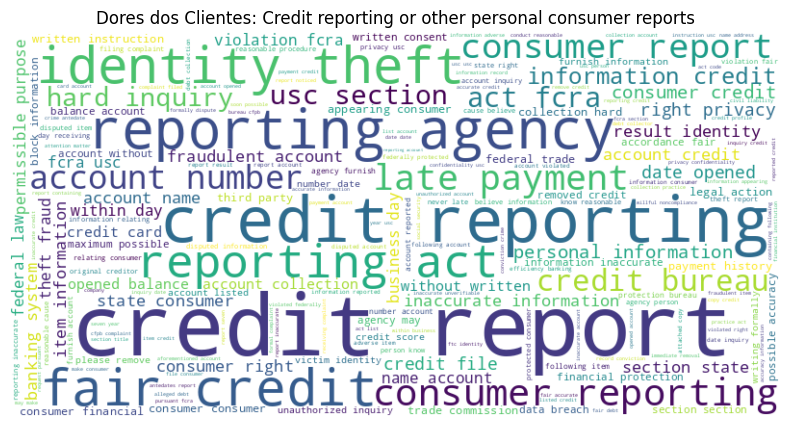

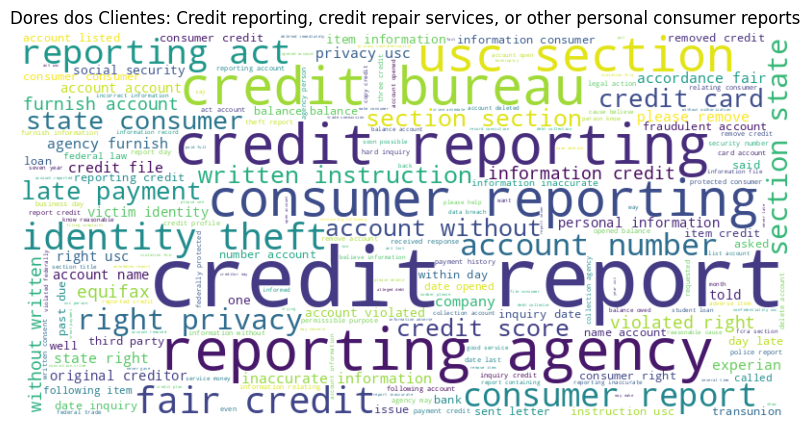

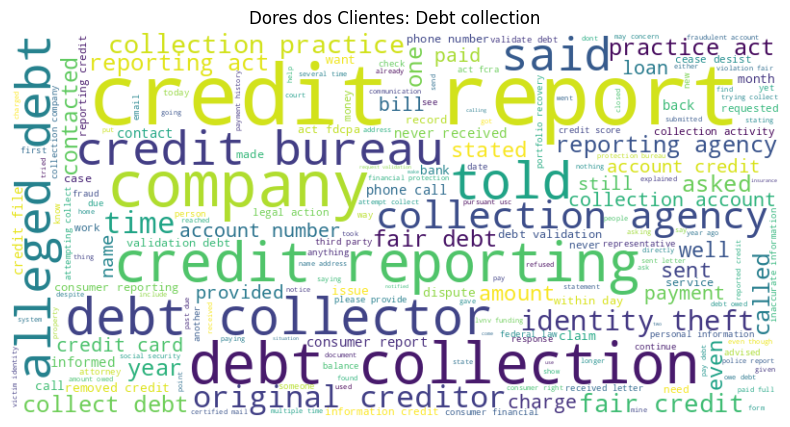

In [24]:
def plot_wordcloud(product_name):
    subset = df[(df['Product'] == product_name) & (df['sentimento'] == 'Negativo')]
    text = " ".join(subset['text_clean'])

    if not text:
        print(f"Sem dados suficientes para {product_name}")
        return

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Dores dos Clientes: {product_name}")
    plt.axis('off')
    plt.show()

# Vamos ver as principais categorias
top_products = df['Product'].value_counts().head(3).index
for prod in top_products:
    plot_wordcloud(prod)

### Gráfico de Frequência de Temas

Vamos olhar os problemas (Issue) mais comuns nas reclamações negativas.

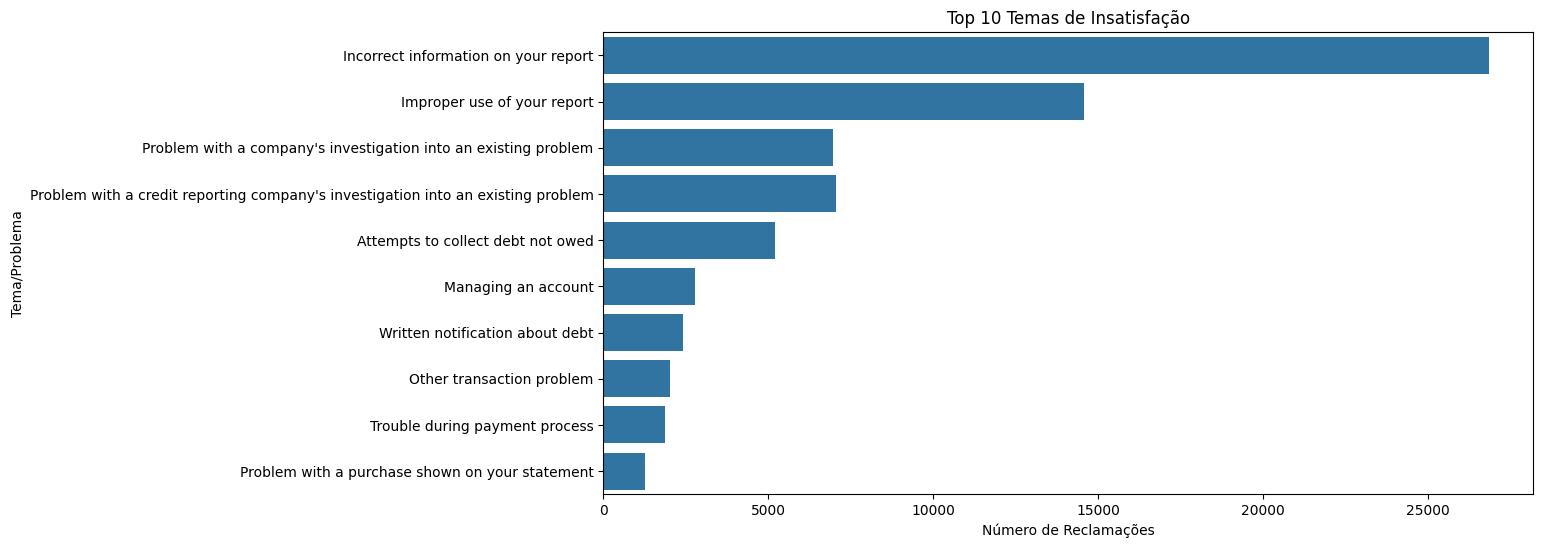

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['sentimento'] == 'Negativo'], y='Issue', order=df['Issue'].value_counts().iloc[:10].index)
plt.title('Top 10 Temas de Insatisfação')
plt.xlabel('Número de Reclamações')
plt.ylabel('Tema/Problema')
plt.show()

## Conclusão

Neste trabalho, conseguimos:
1. Processar uma base real de 143.563 reclamações financeiras.
2. Criar um pipeline de limpeza de texto eficiente.
3. Treinar um modelo de Deep Learning (LSTM) para identificar o sentimento.
4. Identificar visualmente que problemas como **'Incorrect information on your report'** e **'Information belongs to someone else'** são as maiores dores dos clientes no setor de crédito.